In [2]:

! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

  Using cached faiss_cpu-1.13.2-cp310-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
Using cached faiss_cpu-1.13.2-cp310-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (23.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 970.7 kB/s eta 0:00:000:0100:01m


In [4]:
pip install langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [6]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [7]:
load_dotenv()

True

In [8]:
llm = ChatOpenAI(model= "gpt-4o-mini")

In [9]:
loader = PyPDFLoader("/home/tacktile/LangGraph-Tutorial/restructured_1-6.pdf")
docs = loader.load()

In [12]:
docs[0].page_content[:500]

'Simple Invoice Manager\n(SIM) — RAG-Optimized\nKnowledge Base\nThis knowledge base is structured for retrieval-augmented generation (RAG). Each section begins with a [Topic]\nlabel for accurate chunk retrieval. Tables are converted to bullet points. FAQs are included at the end of each\nsection.\nTable of Contents\n1. Company / Business Setup\n2. Clients & Suppliers\n3. Products & Services\n4. Invoices\n5. Estimates / Proforma Invoices\n6. Sale Orders\n7. Expense Management\n[Topic: Company Business Setup]\n1.'

In [13]:
len(docs)

18

In [14]:
splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap= 200)
chunks = splitter.split_documents(docs)

In [15]:
len(chunks)

50

In [16]:
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [17]:
vector_store

In [18]:
retriever = vector_store.as_retriever(search_type= 'mmr', search_kwargs= {'k':4})

In [24]:
retriever.invoke("How to create Invoice?")[0].page_content[:200]

'Dashboard → Side Menu ( ☰ ) → Invoice → Add New Invoice\nActions After Invoice Creation\nAfter creating an invoice, you can perform various actions by clicking on the invoice from invoice list. These ac'

In [19]:
@tool
def rag_tool(query):
    """
    Retrieves relevant information from a pdf document.
    Use this tool when use ask factual/conceptual questions that might be answered from tored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {'query': query, 'context': context, 'metadata': metadata}

In [25]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [26]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [27]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [28]:
tool_node = ToolNode(tools= tools)

In [31]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

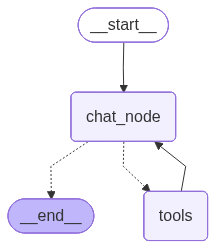

In [32]:
chatbot

In [39]:
final_result = chatbot.invoke({'messages': [HumanMessage(content= "How to create Invoice and what are the steps?")]})
print(final_result['messages'][-1].content)

Creating an invoice typically involves several key steps to ensure that it is clear, professional, and contains all necessary information. Here’s a step-by-step guide:

### Step 1: Choose an Invoice Template
- **Select a Template**: Use a digital template from software like Microsoft Word, Excel, Google Docs, or specific invoicing software (e.g., FreshBooks, QuickBooks).
- **Customization**: Ensure the template can be customized to fit your branding (logo, colors).

### Step 2: Include Your Business Information
- **Your Company Name**: Display your business name prominently at the top.
- **Contact Information**: Include your business address, phone number, email, and website.

### Step 3: Add Client Information
- **Client’s Name**: Clearly state the name of the client or company receiving the invoice.
- **Client’s Contact Information**: Add their address, phone number, and email address if applicable.

### Step 4: Assign an Invoice Number
- **Unique Invoice Number**: Generate a unique 